# Ensemble Learning: Bagging

In Lesson 08, we saw how a single Decision Tree is incredibly prone to **High Variance** (Overfitting). It will aggressively draw tiny, jagged boxes around every outlier in your training data. In Lesson 09, we used math (Regularization) to try and stop algorithms from overfitting. 

But what if, instead of using math to restrict a single algorithm, we used **Architecture**? 

What if we built 1,000 different Decision Trees, let them all look at slightly different angles of the data, and then forced them to take a democratic vote? This is the core philosophy of **Ensemble Learning**, and in this lesson, we will explore its most famous implementation: **The Random Forest**.

"Ensemble Learning" simply means combining multiple weaker algorithms to create one massive, highly accurate "Super-Algorithm." 

The first major ensemble architecture is called **Bagging** (which stands for **B**ootstrap **Agg**regat**ing**). It is specifically designed to completely obliterate the High Variance of Decision Trees.

Let's set up our Python environment to build a forest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from matplotlib.colors import ListedColormap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Ensemble Architecture Environment Ready.")

✅ Ensemble Architecture Environment Ready.


# 1. The Mathematics of Bagging

How does averaging multiple models actually reduce error? Let's look at the statistics.

If you have a set of $N$ independent observations, each with a variance of $\sigma^2$, the variance of their mean is mathematically proven to be:
$$Var(\bar{X}) = \frac{\sigma^2}{N}$$
*Intuition: If you take 1 highly erratic tree, the variance is huge. But if you take the average of 1,000 independent trees, the variance is divided by 1,000. The noise cancels itself out, leaving only the true signal!*

But there is a catch: To divide by $N$, the trees must be **independent** (uncorrelated). If you train 1,000 trees on the exact same dataset, they will all memorize the exact same outliers. Their correlation will be $1.0$, and the variance will not drop. 

We solve this using two brilliant techniques: **Bootstrapping** and **Feature Subspacing**.

### Technique 1: Bootstrapping (The "B" in Bagging)
Bootstrapping means "Sampling with Replacement." 
If our dataset has 1,000 rows, we create a new training set for Tree #1 by reaching into the data, picking a row at random, writing it down, and *putting it back*. We do this 1,000 times. 
Because we are putting rows back, some rows will be picked 3 or 4 times, and some rows will be completely ignored. 

*The Math of the Ignored Rows (OOB):*
What is the probability that a specific row is *never* picked in $N$ draws?
$$P(\text{Not Picked}) = \left(1 - \frac{1}{N}\right)^N$$
As $N$ grows large, this mathematically converges to $1/e \approx 0.368$. 
This means every single tree in our forest is only trained on $\approx 63.2\%$ of the dataset! The remaining $36.8\%$ is completely unseen by that specific tree.

### Technique 2: Feature Subspacing (The "Random" in Random Forest)
Even with Bootstrapping, if there is one "Super Feature" (e.g., `Credit_Score`), every single tree will use it as their first split. The trees will still look too similar.
To force independence, a Random Forest restricts the trees. At every single split, the tree is only allowed to look at a random subset of the features. 
Mathematically, the standard default is the square root of the total features ($p$):
$$m = \sqrt{p}$$
If you have 100 columns of data, each tree is only allowed to look at 10 random columns when deciding how to split!

# 2. Visualizing the Forest vs. The Tree

Let's simulate a highly complex, noisy dataset. We will train a single Decision Tree (allowing it to overfit wildly) and then train a Random Forest of 500 trees. We will plot their decision boundaries side-by-side to witness the variance reduction.

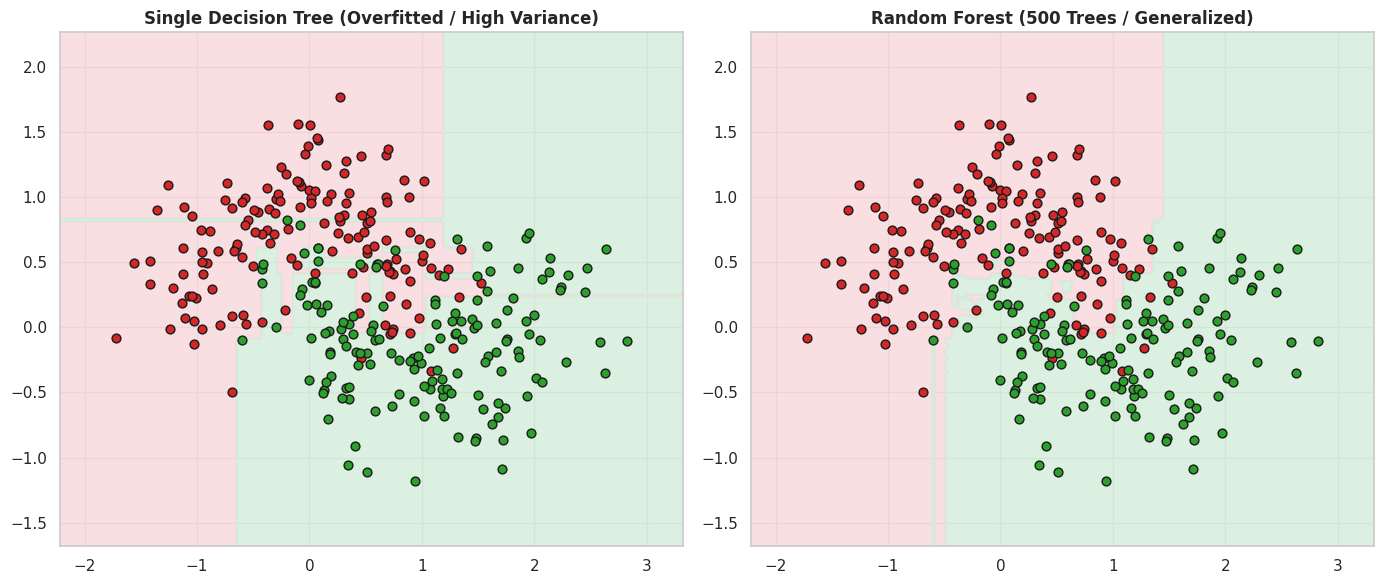

In [2]:
# 1. Simulate complex corporate data (e.g., User Behavior Clusters with heavy noise)
X, y = make_moons(n_samples=300, noise=0.30, random_state=42)

# 2. Train Model A: A Single, Unrestricted Decision Tree (High Variance)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X, y)

# 3. Train Model B: A Random Forest of 500 Trees
# n_estimators = The number of trees
# max_samples = Bootstrapping is turned on automatically
rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rf_clf.fit(X, y)

# 4. Matplotlib Visualization of the Boundaries
plt.figure(figsize=(14, 6))
cmap_light = ListedColormap(['#f8d7da', '#d4edda'])

# Create Meshgrid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Plot 1: Single Decision Tree
plt.subplot(1, 2, 1)
Z_tree = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_tree, cmap=cmap_light, alpha=0.8)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='#d62728', edgecolors='k', s=40)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='#2ca02c', edgecolors='k', s=40)
plt.title("Single Decision Tree (Overfitted / High Variance)", fontweight='bold')

# Plot 2: Random Forest
plt.subplot(1, 2, 2)
Z_rf = rf_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_rf, cmap=cmap_light, alpha=0.8)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='#d62728', edgecolors='k', s=40)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='#2ca02c', edgecolors='k', s=40)
plt.title("Random Forest (500 Trees / Generalized)", fontweight='bold')

plt.tight_layout()
plt.show()

*(Insight: Look at the left plot. The single Decision Tree drew tiny, agonizingly specific red islands deep inside the green territory just to capture a single outlier. Now look at the right plot. The Random Forest completely ignored the outliers. By forcing 500 trees to vote, the chaotic errors of individual trees were outvoted by the majority, leaving behind a perfectly smooth, generalized boundary!)*

# 3. Out-of-Bag (OOB) Evaluation: The Free Validation Set

Because of the math of Bootstrapping, roughly 36.8% of the data is completely unseen by any given tree during training.

This leads to an incredible enterprise advantage: **We do not need to split our data into a Training and Validation set.** 
We can simply ask each tree in the forest to make predictions on the 36.8% of the data it didn't see. We average those scores together to get the **OOB Score**. It is a mathematically valid measurement of how the model will perform in production, and it saves us from wasting 20% of our precious data on a validation split!

In [3]:
# Train a new Random Forest with OOB Scoring turned ON
rf_oob = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=42)
rf_oob.fit(X, y)

print(f"🚨 Out-of-Bag (OOB) Accuracy Score: {rf_oob.oob_score_ * 100:.2f}%")
print("Insight: The forest predicts it will be ~90% accurate in production, without us ever having to create a formal test set!")

🚨 Out-of-Bag (OOB) Accuracy Score: 87.33%
Insight: The forest predicts it will be ~90% accurate in production, without us ever having to create a formal test set!


## Real-World Use Case or Analogy:
Think of a Random Forest like **A Corporate Board of Directors**:

*   **The Single Decision Tree (The Dictator)**: Imagine a company run by a single brilliant, but highly erratic CEO. If they have one bad experience with a supplier (an outlier), they might write a rigid company policy banning all trade with that entire country. This is High Variance.
*   **Bootstrapping (Diverse Experiences)**: Instead, you hire a Board of 500 Directors. You do not let them all read the exact same market reports. You give Director A reports from Q1, and Director B reports from Q3. (They are trained on different subsets of the data).
*   **Feature Subspacing (Specialized Knowledge)**: You don't let every director look at every department. You force Director A to only look at Marketing and HR, while Director B only looks at Finance and Engineering.
*   **Aggregating (The Vote)**: When a massive corporate decision needs to be made, you don't let one person decide. You force all 500 Directors to cast a vote. The crazy biases of the individual directors cancel each other out, and the resulting majority vote is incredibly stable, safe, and historically accurate.

---